## Simulate data based on half of one subject's data

We need the empirical distributions for this one subject:

In [ ]:
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv')
df['RT'] = df['RT']*1000 # adjustment for RT
df['fixation'] = df['fixation'].apply(literal_eval)

sub_id = 301
sub_df = df.loc[df['sub_id'] == 301] # No dropped trials, second batch had less errors overall, more trials

Let's build a function to capture the corrected empirical distributions for a subject that discard the top 5% of durations across all empirical distributions lists.

In [2]:
from simulation import get_corrected_empirical_distributions

value_diffs = np.arange(-4, 4.25, 0.25)
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

empirical_distributions = get_corrected_empirical_distributions(
    sub_df, 
    value_diffs, 
    legend=legend, 
    fixation_col=fixation_col, 
    left_value_col=left_value_col, 
    right_value_col=right_value_col, 
    cutoff=0.95
)

Instead of using create trials from `simulation.py`, I will use `odd_sub_df` to act as a stand in. We'll need to clean things up and then generate fixations.

In [3]:
from simulation import generate_fixations

dt = 0.001

trials = sub_df.loc[sub_df['trial'] % 2 == 1].loc[:, ['avgWTP_left', 'avgWTP_right']]
trials['fixation'] = None

rows = []
for idx, r in trials.iterrows():
    fx = generate_fixations(dt, r.avgWTP_left - r.avgWTP_right, empirical_distributions)
    if fx is not None:
        rows.append((idx, fx))

trials_clean = trials.loc[[i for i, _ in rows]].copy()
trials_clean['fixation'] = [fx for _, fx in rows]
my_trials = trials_clean.to_dict(orient="records")

## Inspect single subject model-free analysis

/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_21213/1762459528.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df["choice"] = sub_df["choice"].map({"left": 0, "right": 1})
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returne

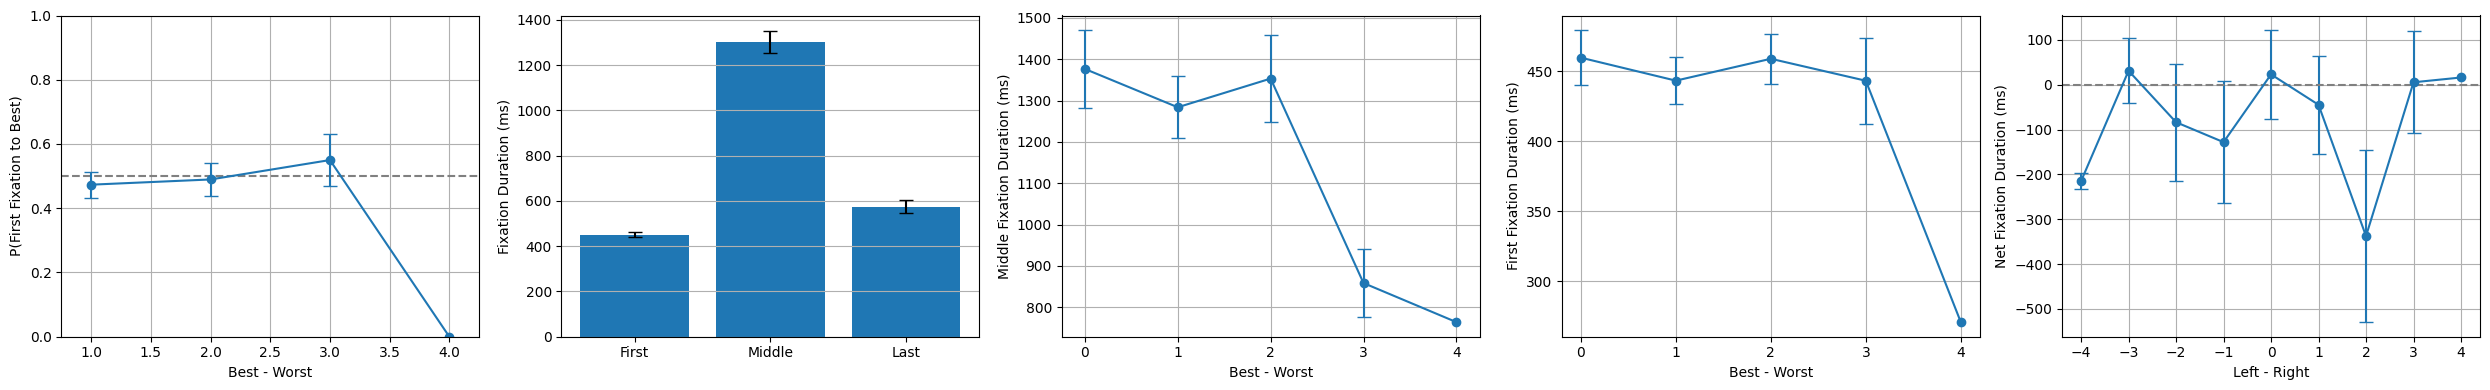

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

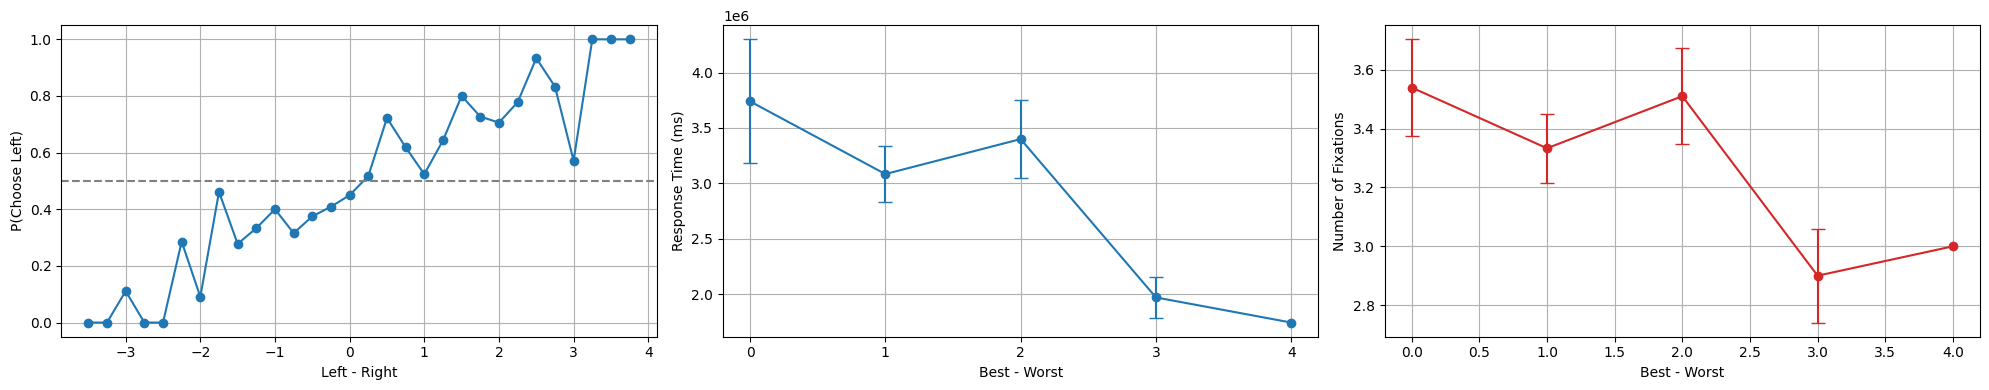

In [12]:
from mfa import plot_basic_psychometrics, plot_fixation_properties
from pyddm.preprocessing.dataset import rasterize_data

sub_df["choice"] = sub_df["choice"].map({"left": 0, "right": 1})

subject_rasterized = rasterize_data(sub_df, subject_col='sub_id',trial_col='trial',seq_col='fixation')

subject_rasterized['fix_dur'] = subject_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

subject_rasterized['fix_num'] = (
    subject_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

subject_rasterized['fix_num_rev'] = (
    subject_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)

plot_fixation_properties(subject_rasterized)
plot_basic_psychometrics(subject_rasterized)

## Simulate trials

In [5]:
from simulation import simulate

seed = 42
model_conditions = {'drift_rate': 0.7, 'theta': 0.5, 'noise': 0.3}

results_df = simulate(dt, model_conditions, my_trials, seed=seed, save_results=False)

results_df['sub_id'] = str(sub_id) + '_sim'
results_df['trial'] = range(1, len(trials_clean) + 1)
results_df = results_df.rename(columns={'fixation': 'fix_sequence'})
results_df = results_df.drop(columns = ['trajectory'])
print(np.average(results_df.loc[:, "RT"]))
results_df.head()

1.871278350515464


,avgWTP_left,avgWTP_right,fix_sequence,RT,choice,sub_id,trial
0,3.00,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.663,0,301_sim,1
1,1.50,3.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.562,1,301_sim,2
2,1.25,1.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.838,1,301_sim,3
3,2.50,2.50,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.757,1,301_sim,4
4,3.00,3.25,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.672,1,301_sim,5


## Rerasterize simulated data

The following should be turned into a function and reworked into the pipeline. We need to create fix_num, fix_num_rev, fix_dur.

In [6]:
import mfa
from pyddm.preprocessing.dataset import rasterize_data

trials_rasterized = rasterize_data(results_df, subject_col='sub_id',trial_col='trial',seq_col='fix_sequence')
trials_rasterized['fix_dur'] = trials_rasterized.apply(
    lambda r: r['fix_end'] - r['fix_start'],
    axis=1
)

trials_rasterized['fix_num'] = (
    trials_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount() + 1
)

trials_rasterized['fix_num_rev'] = (
    trials_rasterized
    .groupby(['sub_id', 'trial'])
    .cumcount(ascending=False) + 1
)
trials_rasterized.head()

,avgWTP_left,avgWTP_right,RT,choice,sub_id,trial,fix_start,fix_end,fix_location,fix_dur,fix_num,fix_num_rev
0,3.00,1.00,1.663,0,301_sim,1,186,940,2,754,1,2
1,3.00,1.00,1.663,0,301_sim,1,955,1662,1,707,2,1
2,1.50,3.50,0.562,1,301_sim,2,186,561,2,375,1,1
3,1.25,1.75,0.838,1,301_sim,3,186,818,2,632,1,2
4,1.25,1.75,0.838,1,301_sim,3,833,837,1,4,2,1


/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_left_by_bin = first_fix_df.groupby('diff_bin')['choice'].apply(lambda x: (x == 0).mean())
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_centers = first_fix_df.groupby('diff_bin')['signed_diff'].mean()
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

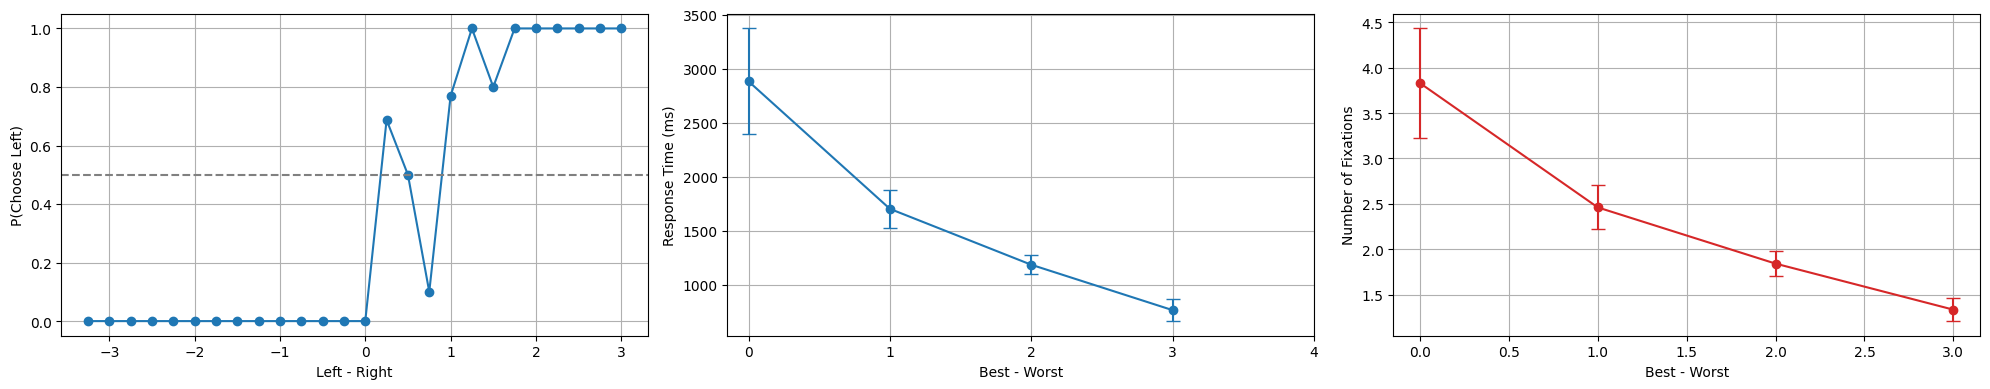

/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = first_fix_df.groupby('diff_bin')['toward_larger'].agg(['mean', sem]).reset_index()
/Users/braydenchien/.pyenv/versions/DDM/lib/python3.12/site-packages/pandas/core/groupby/generic.py:324: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f = lambda x: func(x, *args, **kwargs)
/Users/braydenchien/Desktop/Enkavilab/DDM/mfa.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = middle_fix_df.groupby('di

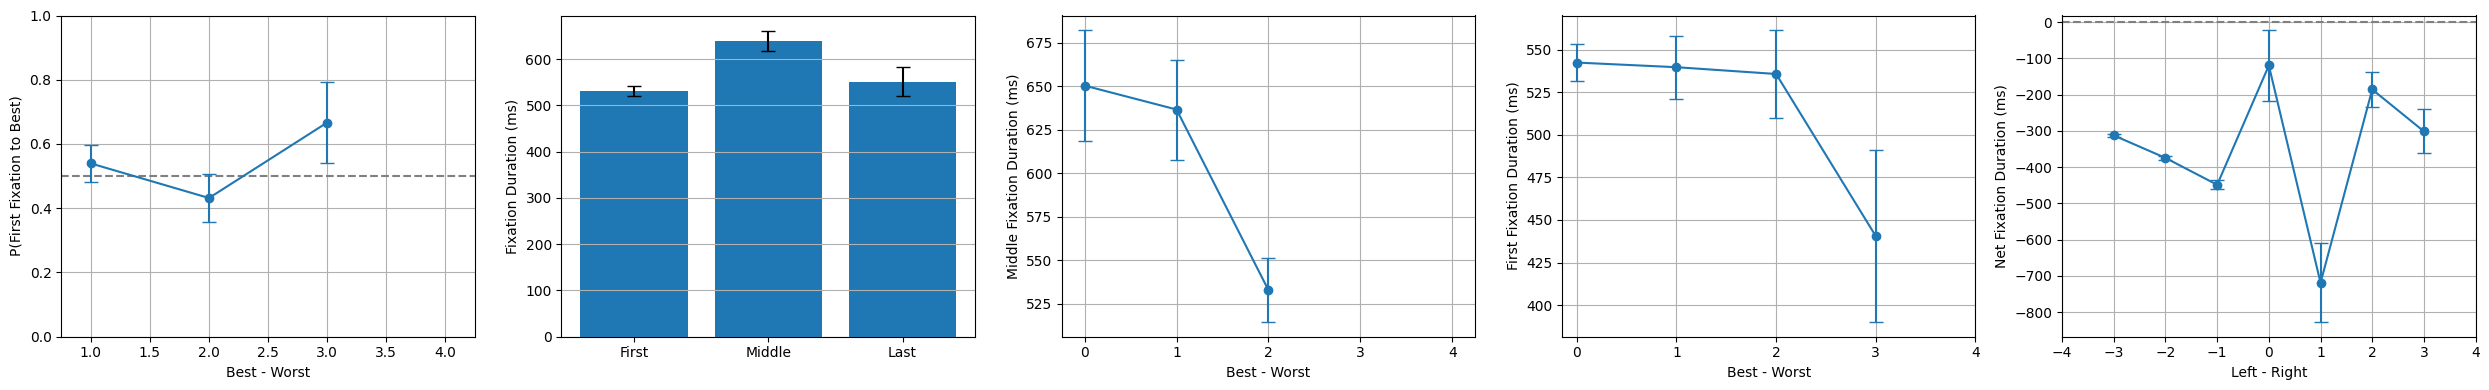

In [7]:
from mfa import plot_basic_psychometrics, plot_fixation_properties

plot_basic_psychometrics(trials_rasterized)
plot_fixation_properties(trials_rasterized)

There are two reasons why the model-free analyses graphs may be different. First, the net fixation duration by relative value difference graph heavily depends on in-sample relative value difference combos. By only isolating one subject's empirical trials, we lose the contributions of many relative value difference combos as each subject have uneven combos hand selected from survey data. Second, and probably still a main issue, perhaps parameters used to estimate the data are unstable. As suggested by the `simple_grid_search` notebook, parameter recovery heavily depends on correct calculations for RT, scalings for model dt, and noise. These confounding factors are present in the simulation pipeline.